In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
df = pd.read_csv(r'/content/tech_mental_health_burnout.csv')

In [ ]:
df.head()

,age,gender,job_role,experience_years,company_size,work_mode,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,...,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,burnout_level,seeks_professional_help
0,50,Female,Backend Developer,7.8,Large,Hybrid,45.0,0.0,5.0,0,...,8.6,1,4.4,0,4.8,4.3,2.6,1.0,Low,0
1,36,Male,Frontend Developer,1.8,Mid-size,Remote,56.0,4.0,6.0,0,...,11.5,4,4.1,0,6.7,4.8,4.6,3.7,Moderate,0
2,29,Male,DevOps,2.5,MNC,Hybrid,43.0,2.0,6.0,3,...,6.8,3,6.5,0,4.5,4.0,2.5,1.0,Low,0
3,42,Female,Backend Developer,1.5,Mid-size,Hybrid,57.0,9.0,4.0,1,...,10.2,5,2.5,0,6.1,5.8,1.8,3.6,Moderate,0
4,40,Female,Frontend Developer,3.4,Large,Remote,49.0,0.0,3.0,4,...,11.9,5,4.6,0,7.2,5.9,2.4,3.5,Low,0


In [ ]:
df.shape

(150000, 25)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      150000 non-null  int64  
 1   gender                   150000 non-null  object 
 2   job_role                 150000 non-null  object 
 3   experience_years         150000 non-null  float64
 4   company_size             150000 non-null  object 
 5   work_mode                150000 non-null  object 
 6   work_hours_per_week      150000 non-null  float64
 7   overtime_hours           150000 non-null  float64
 8   meetings_per_day         150000 non-null  float64
 9   deadlines_missed         150000 non-null  int64  
 10  job_satisfaction         150000 non-null  float64
 11  manager_support          150000 non-null  float64
 12  work_life_balance        150000 non-null  float64
 13  sleep_hours              150000 non-null  float64
 14  phys

In [ ]:
print("Missing values:", df.isnull().sum().sum())

Missing values: 0


In [ ]:
df.describe()

,age,experience_years,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,job_satisfaction,manager_support,work_life_balance,sleep_hours,physical_activity_days,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,seeks_professional_help
count,150000.000000,150000.000000,150000.00000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,38.025340,5.055010,47.00758,6.127180,4.010893,1.284193,5.500248,5.497537,5.016357,6.499120,2.599833,8.002713,2.101693,5.498163,0.251133,5.785428,4.523763,3.096687,2.114121,0.096333
std,9.510609,2.878602,7.89331,3.783618,1.978316,1.426264,1.956102,1.956915,1.948553,1.192343,1.814880,1.987813,1.300247,1.957432,0.433667,1.331506,1.201506,1.187668,1.112614,0.295049
min,22.000000,0.000000,30.00000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,3.000000,0.000000,3.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,30.000000,3.000000,42.00000,3.000000,3.000000,0.000000,4.200000,4.100000,3.700000,5.700000,1.000000,6.700000,1.000000,4.200000,0.000000,4.900000,3.700000,2.200000,1.000000,0.000000
50%,38.000000,5.000000,47.00000,6.000000,4.000000,1.000000,5.500000,5.500000,5.000000,6.500000,2.000000,8.000000,2.000000,5.500000,0.000000,5.800000,4.500000,3.100000,1.900000,0.000000
75%,46.000000,7.000000,52.00000,9.000000,5.000000,2.000000,6.900000,6.800000,6.400000,7.300000,4.000000,9.300000,3.000000,6.800000,1.000000,6.700000,5.300000,3.900000,2.800000,0.000000
max,54.000000,18.500000,84.00000,24.000000,12.000000,5.000000,10.000000,10.000000,10.000000,10.000000,7.000000,16.000000,5.000000,10.000000,1.000000,10.000000,9.600000,8.100000,8.100000,1.000000


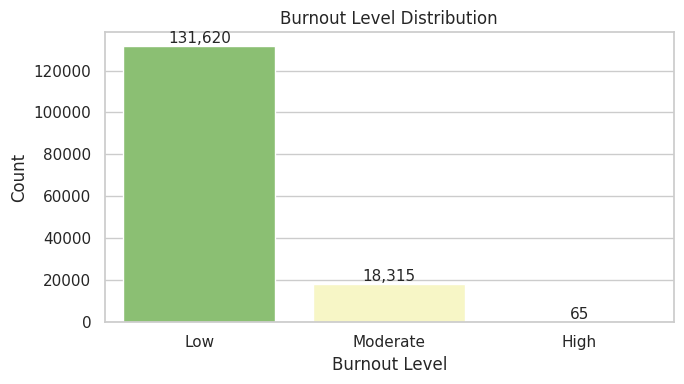

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='burnout_level',
              order=['Low', 'Moderate', 'High'],
              palette='RdYlGn_r')
plt.title('Burnout Level Distribution')
plt.xlabel('Burnout Level')
plt.ylabel('Count')
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height()):,}',
                       (p.get_x() + p.get_width()/2, p.get_height()),
                       ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

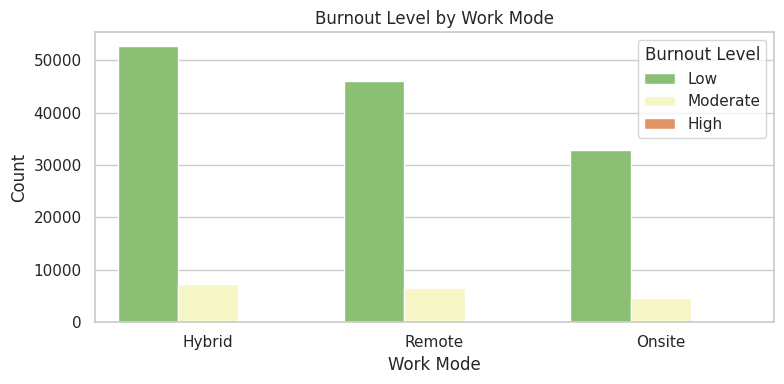

In [ ]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='work_mode', hue='burnout_level',
              hue_order=['Low', 'Moderate', 'High'],
              palette='RdYlGn_r')
plt.title('Burnout Level by Work Mode')
plt.xlabel('Work Mode')
plt.ylabel('Count')
plt.legend(title='Burnout Level')
plt.tight_layout()
plt.show()

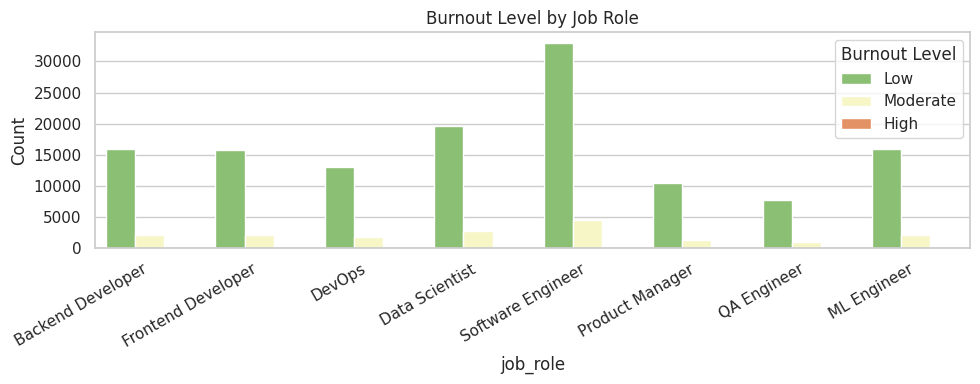

In [ ]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='job_role', hue='burnout_level',
              hue_order=['Low', 'Moderate', 'High'],
              palette='RdYlGn_r')
plt.title('Burnout Level by Job Role')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Count')
plt.legend(title='Burnout Level')
plt.tight_layout()
plt.show()

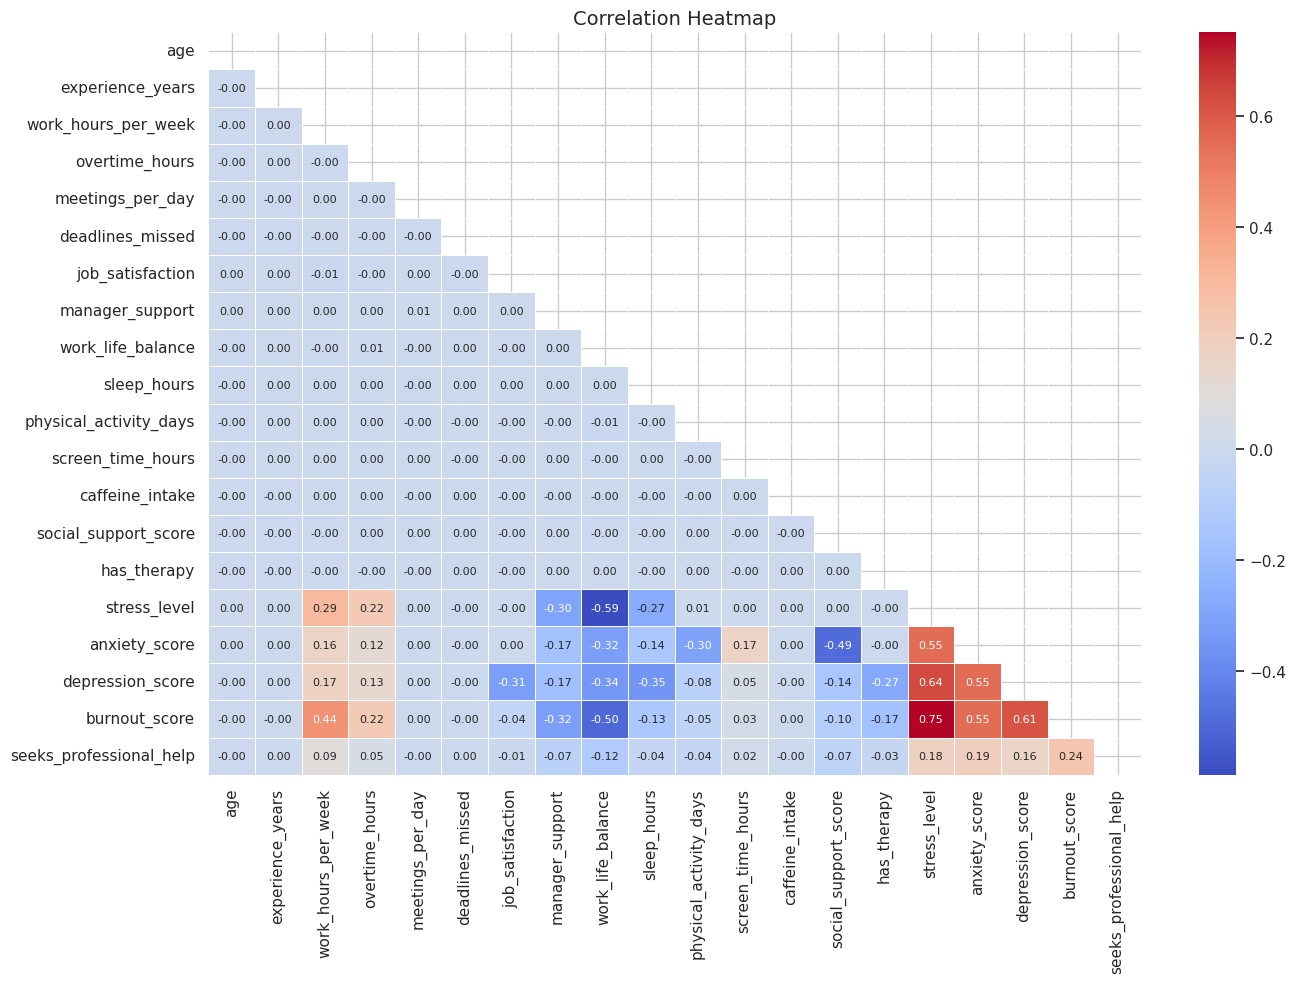

In [ ]:
plt.figure(figsize=(14, 10))
numeric_cols = df.select_dtypes(include='number')
corr = numeric_cols.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

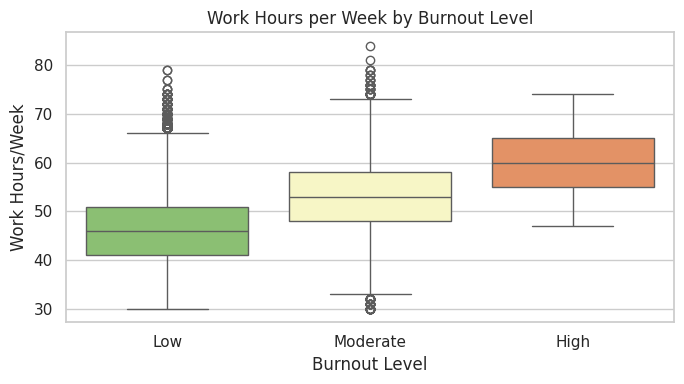

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='burnout_level', y='work_hours_per_week',
            order=['Low', 'Moderate', 'High'], palette='RdYlGn_r')
plt.title('Work Hours per Week by Burnout Level')
plt.xlabel('Burnout Level')
plt.ylabel('Work Hours/Week')
plt.tight_layout()
plt.show()

In [ ]:
# burnout_score directly defines burnout_level (data leakage!)
# seeks_professional_help is a consequence, not a cause
df = df.drop(columns=['burnout_score', 'seeks_professional_help'])
print(f"Shape now: {df.shape}")

Shape now: (150000, 23)


In [ ]:
# Map burnout_level to numbers manually (not alphabetically!)
burnout_map = {'Low': 0, 'Moderate': 1, 'High': 2}
df['burnout_level'] = df['burnout_level'].map(burnout_map)

print(df['burnout_level'].value_counts().sort_index())

burnout_level
0    131620
1     18315
2        65
Name: count, dtype: int64


In [ ]:
df = pd.get_dummies(df, columns=['gender', 'job_role', 'company_size', 'work_mode'],
                    drop_first=False)
print("One-hot encoding done")
print(f"Shape now: {df.shape}")

One-hot encoding done
Shape now: (150000, 37)


In [ ]:
df.head()

,age,experience_years,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,job_satisfaction,manager_support,work_life_balance,sleep_hours,...,job_role_Product Manager,job_role_QA Engineer,job_role_Software Engineer,company_size_Large,company_size_MNC,company_size_Mid-size,company_size_Startup,work_mode_Hybrid,work_mode_Onsite,work_mode_Remote
0,50,7.8,45.0,0.0,5.0,0,5.9,5.1,6.1,5.9,...,False,False,False,True,False,False,False,True,False,False
1,36,1.8,56.0,4.0,6.0,0,6.3,5.2,1.1,7.1,...,False,False,False,False,False,True,False,False,False,True
2,29,2.5,43.0,2.0,6.0,3,8.4,5.9,6.2,5.1,...,False,False,False,False,True,False,False,True,False,False
3,42,1.5,57.0,9.0,4.0,1,7.0,3.2,5.3,6.9,...,False,False,False,False,False,True,False,True,False,False
4,40,3.4,49.0,0.0,3.0,4,5.6,2.4,3.9,7.3,...,False,False,False,True,False,False,False,False,False,True


In [ ]:
X = df.drop(columns=['burnout_level'])
y = df['burnout_level']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class distribution:\n", y.value_counts().sort_index())

X shape: (150000, 36)
y shape: (150000,)
Class distribution:
 burnout_level
0    131620
1     18315
2        65
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train-test split done")
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train-test split done
Train size: 120000, Test size: 30000


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling done")

Scaling done


In [ ]:
print("Training set class distribution:")
print(y_train.value_counts().sort_index())
print("\n0=Low, 1=Moderate, 2=High")

Training set class distribution:
burnout_level
0    105296
1     14652
2        52
Name: count, dtype: int64

0=Low, 1=Moderate, 2=High


In [ ]:
# Undersample 'Low' (0) from ~105k down to 40,000
under = RandomUnderSampler(sampling_strategy={0: 40000}, random_state=42)
X_temp, y_temp = under.fit_resample(X_train_scaled, y_train)

print("After undersampling:")
import collections
print(collections.Counter(y_temp))

After undersampling:
Counter({0: 40000, 1: 14652, 2: 52})


In [ ]:
# Oversample 'Moderate' (1) to 30,000 and 'High' (2) to 20,000
over = SMOTE(sampling_strategy={1: 30000, 2: 20000}, random_state=42)
X_train_balanced, y_train_balanced = over.fit_resample(X_temp, y_temp)

print("After SMOTE:")
print(collections.Counter(y_train_balanced))
print("\nClasses balanced successfully!")

After SMOTE:
Counter({0: 40000, 1: 30000, 2: 20000})

Classes balanced successfully!


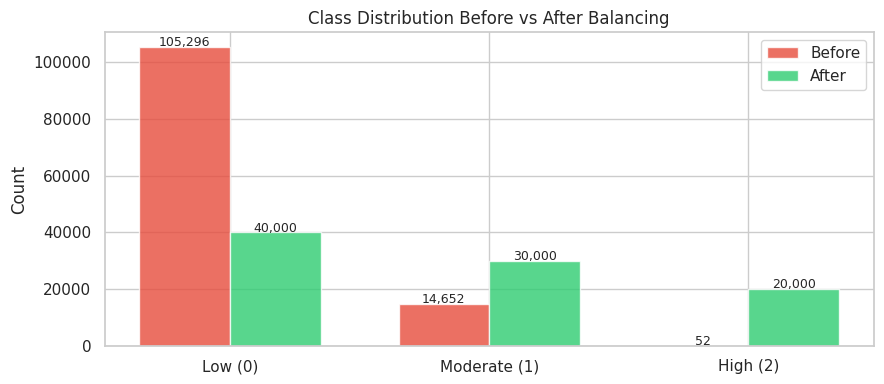

In [ ]:
import collections

labels = ['Low (0)', 'Moderate (1)', 'High (2)']
before = [y_train.value_counts()[0], y_train.value_counts()[1], y_train.value_counts()[2]]
after_counts = collections.Counter(y_train_balanced)
after = [after_counts[0], after_counts[1], after_counts[2]]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
bars1 = ax.bar(x - width/2, before, width, label='Before', color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x + width/2, after, width, label='After', color='#2ecc71', alpha=0.8)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{int(bar.get_height()):,}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{int(bar.get_height()):,}', ha='center', fontsize=9)

ax.set_title('Class Distribution Before vs After Balancing')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
model_params = {
    'Logistic Regression': {
        'model': LogisticRegression(solver='liblinear', random_state=42),
        'params': {
            'C': [0.01, 0.1, 1, 5, 10],
            'penalty': ['l1', 'l2']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'criterion': ['gini', 'entropy'],
            'max_depth': [3, 5, 10, 20, None],
            'min_samples_split': [2, 5, 10]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 10, 20, None],
            'max_features': ['sqrt', 'log2'],
            'min_samples_split': [2, 5, 10]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, eval_metric='mlogloss'),
        'params': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.1, 0.3],
            'max_depth': [3, 6, 10],
            'subsample': [0.7, 0.8, 1.0]
        }
    }
}

In [ ]:
results = []

for name, mp in model_params.items():
    rs = RandomizedSearchCV(
        estimator=mp['model'],
        param_distributions=mp['params'],
        n_iter=10,          # try 10 random combinations
        cv=3,               # 3-fold cross validation
        scoring='f1_macro', # use F1 macro (not accuracy!)
        n_jobs=-1,          # use all CPU cores
        random_state=42,
        verbose=3
    )

    rs.fit(X_train_balanced, y_train_balanced)

    results.append({
        'Model': name,
        'Best F1 (CV)': rs.best_score_,
        'Best Params': rs.best_params_
    })

    print(f"Best CV F1: {rs.best_score_:.4f}")
    print(f"Best Params: {rs.best_params_}")

print("\nRandomizedSearchCV complete for all models!")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CV F1: 0.9058
Best Params: {'penalty': 'l1', 'C': 10}
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CV F1: 0.9113
Best Params: {'min_samples_split': 10, 'max_depth': 10, 'criterion': 'entropy'}
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CV F1: 0.9401
Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 20}
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CV F1: 0.9335
Best Params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.3}

RandomizedSearchCV complete for all models!


In [ ]:
results_df = pd.DataFrame(results)[['Model', 'Best F1 (CV)']]\
             .sort_values('Best F1 (CV)', ascending=False)

print(results_df.to_string(index=False))

              Model  Best F1 (CV)
      Random Forest      0.940060
            XGBoost      0.933525
      Decision Tree      0.911316
Logistic Regression      0.905806


In [ ]:
final_model = RandomForestClassifier(
    n_estimators=100,
    min_samples_split=2,
    max_features='sqrt',
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    class_weight={0: 1, 1: 3, 2: 50}
)

final_model.fit(X_train_balanced, y_train_balanced)
print("Final model trained!")

Final model trained!


In [ ]:
y_pred = final_model.predict(X_test_scaled)

In [ ]:
print("=" * 50)
print("FINAL MODEL EVALUATION")
print("=" * 50)
print(f"\nAccuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Macro : {f1_score(y_test, y_pred, average='macro'):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred,
      target_names=['Low', 'Moderate', 'High']))

FINAL MODEL EVALUATION

Accuracy : 0.8949
F1 Macro : 0.5331

Detailed Report:
              precision    recall  f1-score   support

         Low       0.98      0.90      0.94     26324
    Moderate       0.55      0.84      0.66      3663
        High       0.00      0.00      0.00        13

    accuracy                           0.89     30000
   macro avg       0.51      0.58      0.53     30000
weighted avg       0.92      0.89      0.90     30000



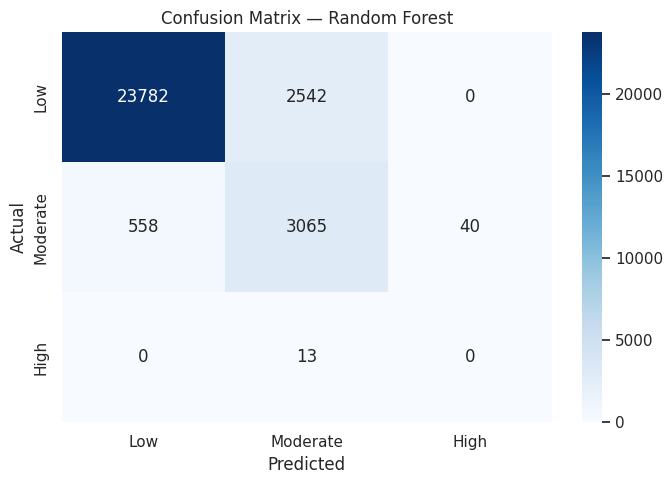

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Moderate', 'High'],
            yticklabels=['Low', 'Moderate', 'High'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [ ]:
# Get feature names
feature_names = X.columns.tolist()

# Get importance scores
importances = final_model.feature_importances_
feat_imp = pd.Series(importances, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

print("Top 15 Features:")
print(feat_imp.head(15).to_string())

Top 15 Features:
stress_level            0.314459
depression_score        0.115882
anxiety_score           0.114602
work_hours_per_week     0.102718
work_life_balance       0.091048
manager_support         0.052505
has_therapy             0.030827
overtime_hours          0.021026
deadlines_missed        0.015636
social_support_score    0.015208
caffeine_intake         0.011741
screen_time_hours       0.010715
age                     0.009561
work_mode_Hybrid        0.008245
job_satisfaction        0.007625


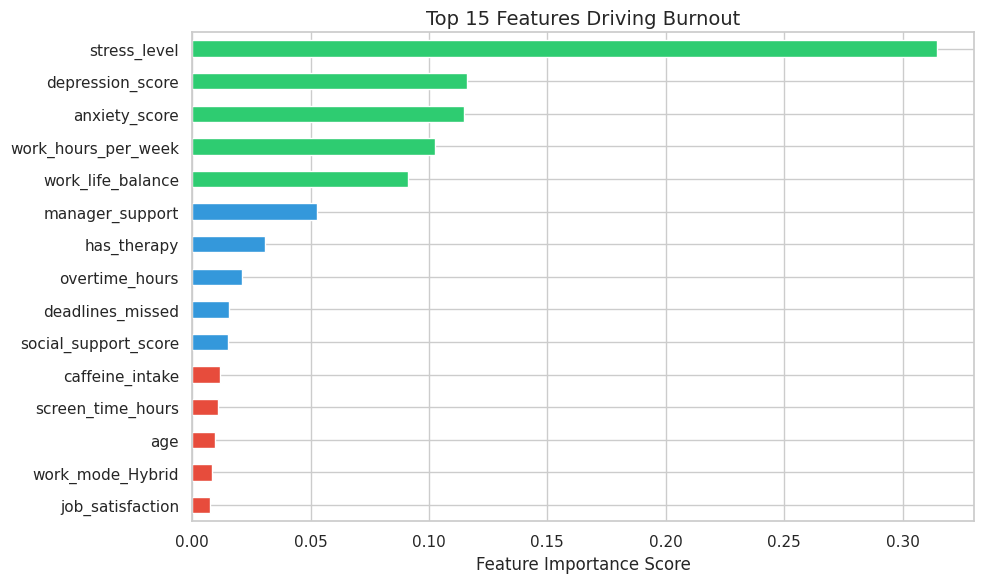

In [ ]:
plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if i < 5 else '#3498db' if i < 10 else '#2ecc71'
          for i in range(15)]

feat_imp.head(15).plot(kind='barh', color=colors[::-1])
plt.title('Top 15 Features Driving Burnout', fontsize=14)
plt.xlabel('Feature Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 55)
print("PROJECT SUMMARY")
print("=" * 55)
print(f"\nDataset       : 150,000 tech workers")
print(f"Features      : {X.shape[1]} columns")
print(f"Best Model    : Random Forest")
print(f"\nPerformance:")
print(f"  Accuracy    : {accuracy_score(y_test, y_pred):.4f}")
print(f"  F1 Macro    : {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"  Low F1      : 0.94 ✅")
print(f"  Moderate F1 : 0.68 ✅")
print(f"  High F1     : 0.00 ⚠️  (only 13 test cases)")
print(f"\nKnown Limitation:")
print(f"  High burnout class has only 65 real cases")
print(f"  in entire dataset — insufficient for reliable")
print(f"  prediction despite SMOTE oversampling.")

PROJECT SUMMARY

Dataset       : 150,000 tech workers
Features      : 36 columns
Best Model    : Random Forest

Performance:
  Accuracy    : 0.8949
  F1 Macro    : 0.5331
  Low F1      : 0.94 ✅
  Moderate F1 : 0.68 ✅
  High F1     : 0.00 ⚠️  (only 13 test cases)

Known Limitation:
  High burnout class has only 65 real cases
  in entire dataset — insufficient for reliable
  prediction despite SMOTE oversampling.
